# Feline Emotion Classifier
Fine-tunes EfficientNet-B0 on one species at a time from the feline emotion dataset.

**Dataset structure:**
```
Sorted_felines 2/Sorted_felines/
    sorted_CzechLynx_bo.../   ← species folder
        angry/                ← emotion (class label)
        happy/
        ...
    sorted_Leopard/
    sorted_cat/
    atrw_reid_train_sorted/
    ...
```

**How to use:**
1. Run all cells top to bottom
2. In the **Config** cell, set `SPECIES` to whichever species you want to train
3. Run training — model saves to Google Drive automatically

## 1. Setup — install packages & mount Drive

In [12]:
# Fix the PIL/_typing conflict and install what we need
!pip install -q --upgrade Pillow
!pip install -q torchvision rembg

print('Done. If you see a RESTART RUNTIME button above, click it, then continue from Cell 2.')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

Done. If you see a RESTART RUNTIME button above, click it, then continue from Cell 2.
Mounted at /content/drive
Drive mounted.


## 2. Download dataset



In [13]:
# Point directly to your Drive folder instead of Kaggle
import os
FELINES_ROOT = '/content/drive/MyDrive/ROB430_Deep_Learning/felines/sorted_tigers/'


emotions = sorted([e for e in os.listdir(FELINES_ROOT)
                   if os.path.isdir(os.path.join(FELINES_ROOT, e))])

print(f'Found: {FELINES_ROOT}')
print(f'Emotions ({len(emotions)}):')
for e in emotions:
    n = len(os.listdir(os.path.join(FELINES_ROOT, e)))
    print(f'  {e:<20} {n} images')

Found: /content/drive/MyDrive/ROB430_Deep_Learning/dogs/
Emotions (8):
  angry                20 images
  curious              206 images
  fear                 37 images
  happy                245 images
  neutral              372 images
  relaxed              133 images
  surprised            14 images
  unhappy              36 images


## 3. Config — set your species here
Change `SPECIES` to any folder name printed above, e.g. `'sorted_cat'` or `'sorted_Leopard'`

In [14]:
SPECIES = 'tigers'

EPOCHS      = 60
BATCH_SIZE  = 32
LR          = 1e-4
IMG_SIZE    = 224
USE_REMBG   = False

DRIVE_SAVE  = f'/content/drive/MyDrive/ROB430_Deep_Learning/{SPECIES}'
os.makedirs(DRIVE_SAVE, exist_ok=True)

SPECIES_DIR = FELINES_ROOT  # ← changed this line

emotions = sorted([e for e in os.listdir(SPECIES_DIR)
                   if os.path.isdir(os.path.join(SPECIES_DIR, e))])
print(f'Training on: {SPECIES}')
print(f'Classes ({len(emotions)}):')
for e in emotions:
    n = len(os.listdir(os.path.join(SPECIES_DIR, e)))
    print(f'  {e:<20} {n} images')

Training on: dogs
Classes (8):
  angry                20 images
  curious              206 images
  fear                 37 images
  happy                245 images
  neutral              372 images
  relaxed              133 images
  surprised            14 images
  unhappy              36 images


## 4. Train

In [15]:
!pip install -q --upgrade numpy onnxruntime

In [16]:
# ── Preprocess sorted_cat images → /content/processed_cats ────────────────
import os
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm.notebook import tqdm
from rembg import remove, new_session

PROCESSED_DIR = f'/content/drive/MyDrive/ROB430_Deep_Learning/processed_tigers'   # temporary, lives in Colab RAM/disk
                                             # deleted when runtime resets

# Only run if not already done (so re-running the cell doesn't redo everything)
if not os.path.exists(PROCESSED_DIR) or len(list(Path(PROCESSED_DIR).rglob('*.png'))) == 0:

    print('Loading ISNet model (~170MB one-time download)...')
    session = new_session('isnet-general-use')
    print('Model ready.\n')

    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    all_images = [p for p in Path(FELINES_ROOT).rglob('*')   # ← use FELINES_ROOT not SPECIES_DIR
              if p.suffix.lower() in image_extensions]

    print(f'Preprocessing {len(all_images)} images from {SPECIES_DIR}')
    print(f'Saving to {PROCESSED_DIR}\n')

    ok, skipped = 0, 0
    for img_path in tqdm(all_images, desc='Preprocessing'):

        # Mirror the folder structure: SPECIES_DIR/angry/cat1.jpg
        #                          → PROCESSED_DIR/angry/cat1.png
        rel = img_path.relative_to(FELINES_ROOT)
        out_path = Path(PROCESSED_DIR) / rel.with_suffix('.png')
        out_path.parent.mkdir(parents=True, exist_ok=True)

        if out_path.exists():    # skip if already processed
            ok += 1
            continue

        try:
            img  = Image.open(img_path).convert('RGBA')
            rgba = remove(img, session=session)

            # Crop tightly around the animal
            mask = np.array(rgba)[:, :, 3]
            rows, cols = np.any(mask > 0, axis=1), np.any(mask > 0, axis=0)
            if rows.any():
                r0, r1 = np.where(rows)[0][[0, -1]]
                c0, c1 = np.where(cols)[0][[0, -1]]
                h, w   = mask.shape
                rgba   = rgba.crop((max(0,c0-20), max(0,r0-20),
                                    min(w,c1+20), min(h,r1+20)))

            # White background, resize to 224x224, save as PNG
            bg = Image.new('RGB', rgba.size, (255, 255, 255))
            bg.paste(rgba, mask=rgba.split()[3])
            bg.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS).save(out_path)
            ok += 1

        except Exception as e:
            print(f'  [SKIP] {img_path.name}: {e}')
            skipped += 1

    print(f'\nDone. {ok} processed, {skipped} skipped.')

else:
    n = len(list(Path(PROCESSED_DIR).rglob('*.png')))
    print(f'Processed images already exist ({n} files) — skipping preprocessing.')

# Point SPECIES_DIR at the clean images for training
SPECIES_DIR = PROCESSED_DIR
print(f'\nSPECIES_DIR updated to: {SPECIES_DIR}')

Loading ISNet model (~170MB one-time download)...
Model ready.

Preprocessing 1064 images from /content/drive/MyDrive/ROB430_Deep_Learning/dogs/
Saving to /content/drive/MyDrive/ROB430_Deep_Learning/processed_dogs



Preprocessing:   0%|          | 0/1064 [00:00<?, ?it/s]


Done. 1064 processed, 0 skipped.

SPECIES_DIR updated to: /content/drive/MyDrive/ROB430_Deep_Learning/processed_dogs


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import csv, time
from pathlib import Path
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')


# ── Dataset ────────────────────────────────────────────────────────────────

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

class FelineDataset(Dataset):
    """Loads images from species_dir/<emotion>/ folders."""
    def __init__(self, species_dir, transform=None, cache=True):
        self.transform  = transform
        self.cache      = cache
        self._cache_d   = {}
        self.classes    = sorted([d for d in os.listdir(species_dir)
                                  if os.path.isdir(os.path.join(species_dir, d))])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples = []
        self.test_samples = []
        for cls in self.classes:
            cls_dir = os.path.join(species_dir, cls)
            imgs = sorted([str(f) for f in Path(cls_dir).iterdir()
                          if f.suffix.lower() in IMG_EXTS])
            label = self.class_to_idx[cls]
            self.samples      += [(p, label) for p in imgs[:-5]]
            self.test_samples += [(p, label) for p in imgs[-5:]]
        print(f'  {len(self.samples)} images, {len(self.classes)} classes: {self.classes}')
    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
      path, label = self.samples[idx]
      if idx in self._cache_d:
          img = self._cache_d[idx]
      else:
          img = Image.open(path).convert('RGB')
          if self.cache: self._cache_d[idx] = img
      if self.transform: img = self.transform(img)
      return img, label

    def class_weights(self):
        counts = torch.zeros(len(self.classes))
        for _, l in self.samples: counts[l] += 1
        w = 1.0 / torch.clamp(counts, min=1)
        return torch.tensor([w[l].item() for _, l in self.samples])

# ── Transforms ─────────────────────────────────────────────────────────────

train_tf = T.Compose([
    T.Resize((224, 224)),  # ADD
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = T.Compose([
    T.Resize((224, 224)),  # ADD
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


# ── Build datasets ─────────────────────────────────────────────────────────

print('Loading dataset...')
full_ds = FelineDataset(SPECIES_DIR, transform=train_tf)

# Add this right after: full_ds = FelineDataset(...)
test_ds = FelineDataset.__new__(FelineDataset)
test_ds.classes    = full_ds.classes
test_ds.class_to_idx = full_ds.class_to_idx
test_ds.samples    = full_ds.test_samples
test_ds.transform  = val_tf
test_ds.cache      = True
test_ds._cache_d   = {}
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'Test samples held out: {len(test_ds.samples)}')

n_val   = max(1, int(len(full_ds) * 0.2))
n_train = len(full_ds) - n_val
train_sub, val_sub = random_split(full_ds, [n_train, n_val],
                                  generator=torch.Generator().manual_seed(42))

# Separate val dataset with no augmentation
val_ds = FelineDataset.__new__(FelineDataset)
val_ds.classes     = full_ds.classes
val_ds.class_to_idx = full_ds.class_to_idx
val_ds.samples     = [full_ds.samples[i] for i in val_sub.indices]
val_ds.transform   = val_tf
val_ds.cache       = True
val_ds._cache_d    = {}

# Weighted sampler for class imbalance
sw = full_ds.class_weights()
train_sw = sw[[i for i in train_sub.indices]]
sampler = WeightedRandomSampler(train_sw, len(train_sw), replacement=True)

train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {n_train}  Val: {n_val}')

# ── Model ──────────────────────────────────────────────────────────────────

num_classes = len(full_ds.classes)
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),          # ADD
    nn.Linear(1280, num_classes)
)
model = model.to(device)

# Split LR: backbone gets 1e-5, head gets 1e-3
optimizer = optim.Adam([
    {'params': model.features.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# ── Training loop ──────────────────────────────────────────────────────────

log_path  = os.path.join(DRIVE_SAVE, 'training_log.csv')
best_acc  = 0.0

with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch','train_loss','train_acc','val_loss','val_acc'])

print(f'\nTraining {SPECIES} for {EPOCHS} epochs...')
print('='*55)

for epoch in range(1, EPOCHS + 1):
    # Instead of all-or-nothing at epoch 11, unfreeze in stages
    if epoch == 1:
        for param in model.features.parameters():
            param.requires_grad = False
    if epoch == 11:
        # Unfreeze only the last 2 blocks first
        for param in model.features[-3:].parameters():
            param.requires_grad = True
    if epoch == 21:
        # Unfreeze everything
        for param in model.features.parameters():
            param.requires_grad = True
    t0 = time.time()

    # -- Train --
    model.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        tr_loss    += loss.item()
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += labels.size(0)

    # -- Validate --
    model.eval()
    va_loss, va_correct, va_total = 0, 0, 0
    per_cls_c = {}; per_cls_t = {}
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            va_loss    += loss.item()
            preds       = out.argmax(1)
            va_correct += (preds == labels).sum().item()
            va_total   += labels.size(0)
            for l, p in zip(labels, preds):
                l = l.item()
                per_cls_c[l] = per_cls_c.get(l, 0) + (p == l).item()
                per_cls_t[l] = per_cls_t.get(l, 0) + 1

    tr_acc = tr_correct / tr_total
    va_acc = va_correct / va_total
    tr_l   = tr_loss / len(train_loader)
    va_l   = va_loss / len(val_loader)
    scheduler.step(va_l)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{EPOCHS}  ({elapsed:.0f}s)  '
          f'train {tr_acc*100:.1f}%  val {va_acc*100:.1f}%')

    # Per-class breakdown every 5 epochs
    if epoch % 5 == 0:
        for ci, cn in enumerate(full_ds.classes):
            c, t = per_cls_c.get(ci,0), per_cls_t.get(ci,0)
            print(f'  {cn:<18} {c}/{t} = {c/t*100:.0f}%' if t else f'  {cn:<18} no val samples')

    # Save best model
    if va_acc > best_acc:
        best_acc = va_acc
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_acc': va_acc, 'classes': full_ds.classes},
                   os.path.join(DRIVE_SAVE, 'best_model.pt'))
        print(f'  *** Best model saved ({va_acc*100:.1f}%)')

    # Save latest checkpoint
    torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                'val_acc': va_acc, 'classes': full_ds.classes},
               os.path.join(DRIVE_SAVE, 'last_model.pt'))

    with open(log_path, 'a', newline='') as f:
        csv.writer(f).writerow([epoch, f'{tr_l:.4f}', f'{tr_acc:.4f}',
                                 f'{va_l:.4f}', f'{va_acc:.4f}'])

print('='*55)
print(f'Done. Best val accuracy: {best_acc*100:.1f}%')

print('\n' + '='*55)
print('FINAL TEST EVALUATION (never seen during training)')
ckpt = torch.load(os.path.join(DRIVE_SAVE, 'best_model.pt'), map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        test_correct += (model(imgs).argmax(1) == labels).sum().item()
        test_total   += labels.size(0)
print(f'Test accuracy: {test_correct/test_total*100:.1f}%  ({test_correct}/{test_total})')
print(f'Models saved to: {DRIVE_SAVE}')

Device: cuda
GPU: Tesla T4
Loading dataset...
  1023 images, 8 classes: ['angry', 'curious', 'fear', 'happy', 'neutral', 'relaxed', 'surprised', 'unhappy']
Test samples held out: 40
Train: 819  Val: 204

Training dogs for 60 epochs...
Epoch 01/60  (6s)  train 21.0%  val 25.0%
  *** Best model saved (25.0%)
Epoch 02/60  (6s)  train 43.7%  val 27.0%
  *** Best model saved (27.0%)
Epoch 03/60  (6s)  train 50.4%  val 32.4%
  *** Best model saved (32.4%)
Epoch 04/60  (6s)  train 53.8%  val 34.8%
  *** Best model saved (34.8%)
Epoch 05/60  (8s)  train 57.9%  val 30.9%
  angry              0/3 = 0%
  curious            6/42 = 14%
  fear               1/5 = 20%
  happy              36/54 = 67%
  neutral            9/74 = 12%
  relaxed            10/16 = 62%
  surprised          0/3 = 0%
  unhappy            1/7 = 14%
Epoch 06/60  (6s)  train 61.1%  val 34.8%
Epoch 07/60  (7s)  train 58.9%  val 39.2%
  *** Best model saved (39.2%)
Epoch 08/60  (6s)  train 62.4%  val 31.4%
Epoch 09/60  (7s)  tra

## 5. Plot training curves

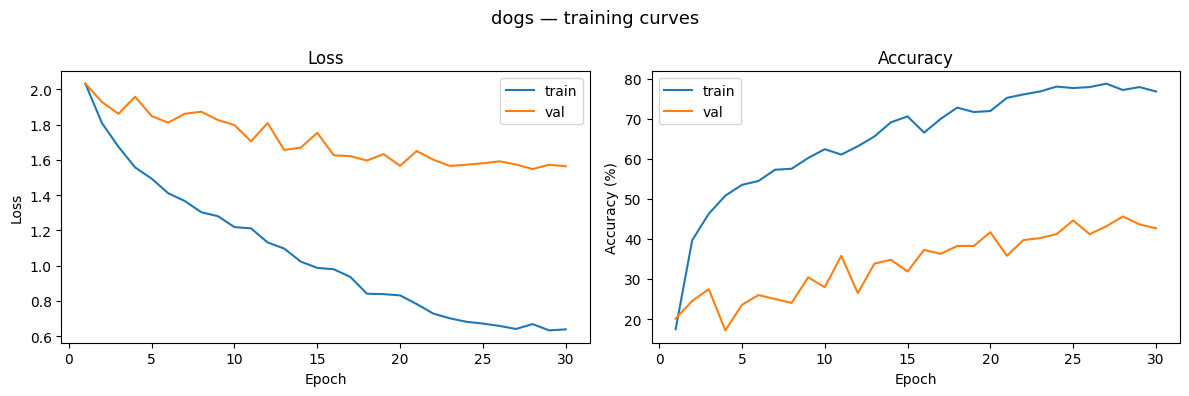

Plot saved to /content/drive/MyDrive/ROB430_Deep_Learning/dogs/training_curves.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(log_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'{SPECIES} — training curves', fontsize=13)

ax1.plot(df.epoch, df.train_loss, label='train')
ax1.plot(df.epoch, df.val_loss,   label='val')
ax1.set(xlabel='Epoch', ylabel='Loss', title='Loss')
ax1.legend()

ax2.plot(df.epoch, df.train_acc * 100, label='train')
ax2.plot(df.epoch, df.val_acc   * 100, label='val')
ax2.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE, 'training_curves.png'), dpi=120)
plt.show()
print(f'Plot saved to {DRIVE_SAVE}/training_curves.png')